## Keel — Graduation-Risk Classifier Training

**Objective.** Train a binary classifier that takes a `(student-state, candidate-plan)`
feature vector and predicts `at_risk ∈ {0, 1}`. The prediction feeds the risk badge
on every proposed plan and the LLM mitigation narrative.

**Three-family bake-off (tabular data — no DL, no LLM baseline):**
- **Model A** — Logistic Regression (linear baseline)
- **Model B** — Random Forest (bagging)
- **Model C** — HistGradientBoosting (boosting)

Each family is trained twice: default params (base) and `RandomizedSearchCV` (tuned).
Six runs total; winner by macro-F1, tie-break by at-risk recall.

**Why no DL / LLM?** This is tabular data (9 numeric features). Deep learning and
LLM baselines are unsuited to tabular regression problems of this size. The
ML/DL/LLM comparison lesson was demonstrated in the intent classifier (text data).
Comparing linear / bagging / boosting is the correct three-way comparison here.

**Class imbalance.** The dataset has ~25% at-risk (minority). We use
`class_weight='balanced'` for LR and RF; for HistGB we compute balanced
`sample_weight` before fitting. No SMOTE — at 25% imbalance, class weighting
is sufficient and avoids the `imbalanced-learn` dependency.

**MLflow.** All runs logged to `keel-grad-risk` experiment. Winner registered
as `keel-grad-risk` → Production.

## 1) Setup

Install packages once, then import everything.

In [1]:
import subprocess, sys

def _ensure(spec, import_name=None):
    pkg  = spec.split("==")[0].split("[")[0].strip()
    name = import_name or pkg
    if "==" in spec:
        req_ver = spec.split("==", 1)[1]
        try:
            from importlib.metadata import version as _v
            if _v(pkg) == req_ver:
                return
        except Exception:
            pass
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", spec])
    else:
        try:
            __import__(name)
        except ImportError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", spec])

# ── ML / training ──────────────────────────────────────────────────────────
_ensure("scikit-learn",      "sklearn")
_ensure("mlflow==2.17.2",    "mlflow")
_ensure("skl2onnx",          "skl2onnx")
_ensure("onnxruntime",       "onnxruntime")
_ensure("pandas",            "pandas")
_ensure("matplotlib",        "matplotlib")
_ensure("seaborn",           "seaborn")
_ensure("pyarrow",           "pyarrow")

print("All packages ready.")

All packages ready.


In [3]:
import hashlib, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, average_precision_score, brier_score_loss,
)
import joblib
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Feature order (must match domain/features/grad_risk.py FEATURE_ORDER) ─
FEATURE_ORDER = [
    "cumulative_gpa",
    "gpa_trend",
    "num_failures",
    "num_repeats",
    "progress_rate",
    "pct_complete",
    "planned_credits",
    "planned_workload_index",
    "num_hard_courses",
]
TARGET = "at_risk"

# ── Data paths ─────────────────────────────────────────────────────────────
DATA_DIR      = Path("/content/data")
DATA_CSV      = DATA_DIR / "grad_risk.csv"
EDGE_CSV      = DATA_DIR / "grad_risk_golden_edge.csv"
ARTIFACTS_DIR = Path("/content/keel_grad_risk_artifacts")
DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ── MLflow ─────────────────────────────────────────────────────────────────
# Run `ngrok http 5001` on your Mac, then paste the URL here.
MLFLOW_TRACKING_URI = "https://paradox-dyslexia-rejoice.ngrok-free.dev"  # UPDATE BEFORE RUNNING
EXPERIMENT_NAME     = "keel-grad-risk"
REGISTRY_NAME       = "keel-grad-risk"

print(f"Feature order : {FEATURE_ORDER}")
print(f"Artifacts dir : {ARTIFACTS_DIR}")

Feature order : ['cumulative_gpa', 'gpa_trend', 'num_failures', 'num_repeats', 'progress_rate', 'pct_complete', 'planned_credits', 'planned_workload_index', 'num_hard_courses']
Artifacts dir : /content/keel_grad_risk_artifacts


### 1b) Data files

Upload `grad_risk.csv` and `grad_risk_golden_edge.csv` to `/content/data/` in the
Colab file browser, then run this cell.

In [4]:
if not DATA_CSV.exists() or not EDGE_CSV.exists():
    raise FileNotFoundError(
        f"Upload both files to {DATA_DIR} in the Colab file browser first:\n"
        "  • grad_risk.csv\n"
        "  • grad_risk_golden_edge.csv\n"
        "(They are in the repo under data/ — drag-and-drop into /content/data/)"
    )

print(f"✓ grad_risk.csv              {DATA_CSV.stat().st_size:,} bytes")
print(f"✓ grad_risk_golden_edge.csv  {EDGE_CSV.stat().st_size:,} bytes")

✓ grad_risk.csv              385,970 bytes
✓ grad_risk_golden_edge.csv  2,361 bytes


### 1c) Connect to MLflow

Run `ngrok http 5001` on your Mac, paste the URL into `MLFLOW_TRACKING_URI` above,
then run this cell.

In [5]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

try:
    _exps = mlflow.search_experiments()
    print("=" * 64)
    print(f"✓ Connected to MLflow at {MLFLOW_TRACKING_URI}")
    print(f"  Experiments found: {len(_exps)}")
    print("=" * 64)
except Exception as _e:
    raise RuntimeError(
        f"Cannot reach MLflow at {MLFLOW_TRACKING_URI}.\n"
        f"Cause: {_e}\n"
        "Check: Docker is up (`docker compose up -d`) and ngrok is running.\n"
        "Update MLFLOW_TRACKING_URI in the constants cell with your current ngrok URL."
    )

2026/06/12 16:00:41 INFO mlflow.tracking.fluent: Experiment with name 'keel-grad-risk' does not exist. Creating a new experiment.


✓ Connected to MLflow at https://paradox-dyslexia-rejoice.ngrok-free.dev
  Experiments found: 3


## 2) EDA

Four plots: class balance, two feature distributions by class, correlation heatmap.
All numeric features — no categorical encoding is needed for this dataset.

In [6]:
df = pd.read_csv(DATA_CSV)
print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print(f"At-risk rate  : {df[TARGET].mean():.3f}  ({df[TARGET].sum()} / {len(df)})")
df.head(3)

Dataset shape : (4000, 11)
Columns       : ['row_id', 'cumulative_gpa', 'gpa_trend', 'num_failures', 'num_repeats', 'progress_rate', 'pct_complete', 'planned_credits', 'planned_workload_index', 'num_hard_courses', 'at_risk']
At-risk rate  : 0.248  (994 / 4000)


,row_id,cumulative_gpa,gpa_trend,num_failures,num_repeats,progress_rate,pct_complete,planned_credits,planned_workload_index,num_hard_courses,at_risk
0,0,2.757988,0.064814,0.0,0.0,0.840000,0.525000,13.0,47.0,1.0,0
1,1,1.991391,0.408497,1.0,1.0,0.506667,0.316667,15.0,60.0,3.0,0
2,2,2.687714,-0.140456,0.0,0.0,0.966667,0.241667,14.0,63.0,4.0,0


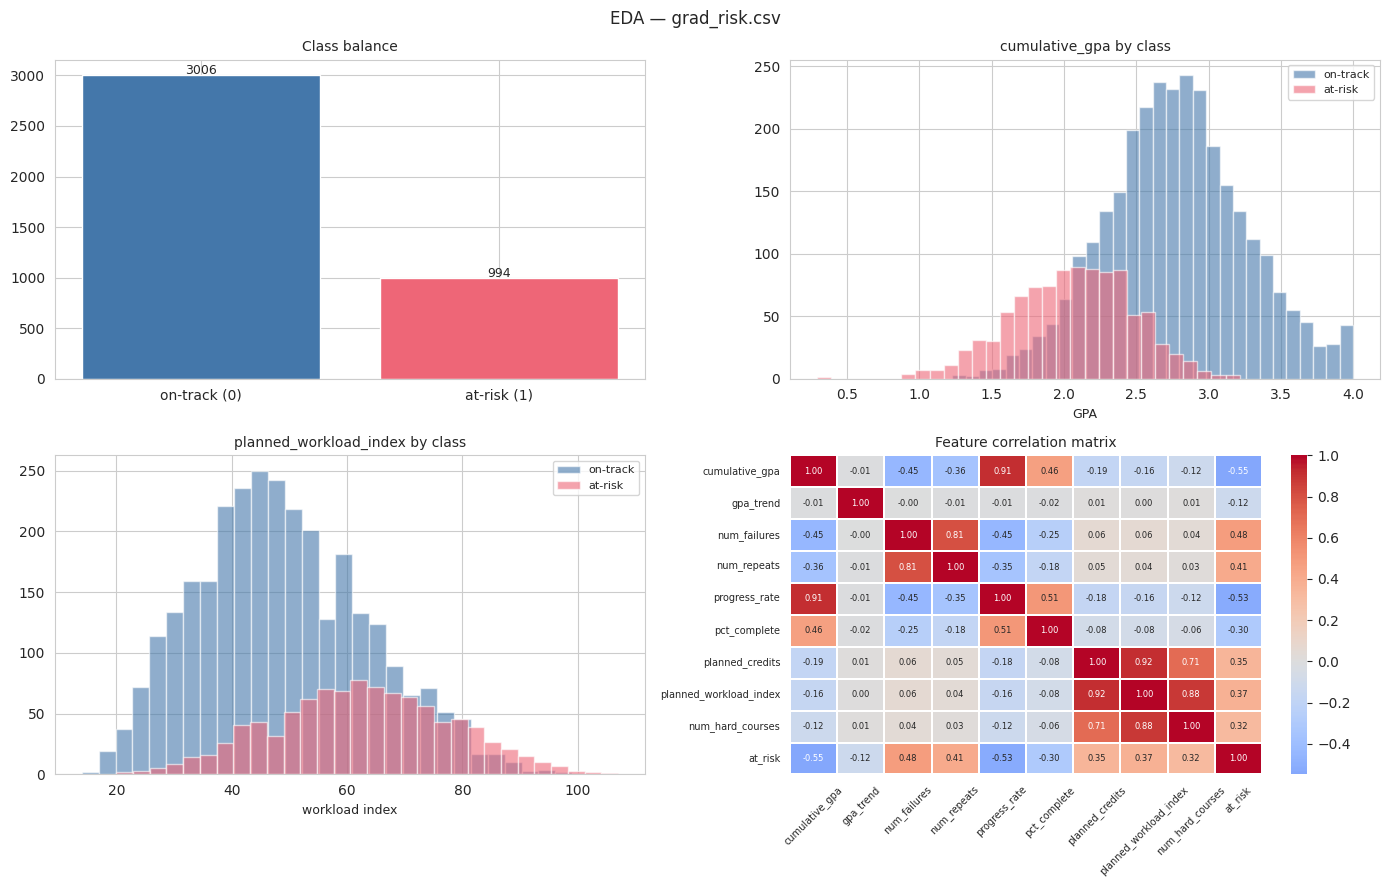


Feature summary:
       cumulative_gpa  gpa_trend  num_failures  num_repeats  progress_rate  pct_complete  planned_credits  planned_workload_index  num_hard_courses
count        4000.000   4000.000      4000.000     4000.000       4000.000      4000.000         4000.000                4000.000          4000.000
mean            2.596     -0.002         1.286        0.762          0.762         0.429           14.193                  52.268             2.458
std             0.563      0.418         1.275        0.950          0.212         0.233            3.117                  16.045             1.363
min             0.290     -1.491         0.000        0.000          0.489         0.067            7.000                  14.000             0.000
25%             2.214     -0.276         0.000        0.000          0.533         0.250           12.000                  41.000             1.000
50%             2.606     -0.005         1.000        1.000          0.750         0.400      

In [7]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ── 2a) Class balance ──────────────────────────────────────────────────────
ax = axes[0, 0]
counts = df[TARGET].value_counts().sort_index()
ax.bar(["on-track (0)", "at-risk (1)"], counts.values, color=["#4477aa", "#ee6677"],
       edgecolor="white")
ax.set_title("Class balance", fontsize=10)
for bar, v in zip(ax.patches, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 10, str(v),
            ha="center", fontsize=9)

# ── 2b) cumulative_gpa by class ────────────────────────────────────────────
ax = axes[0, 1]
for lbl, color, name in [(0, "#4477aa", "on-track"), (1, "#ee6677", "at-risk")]:
    ax.hist(df.loc[df[TARGET] == lbl, "cumulative_gpa"], bins=30, alpha=0.6,
            color=color, label=name, edgecolor="white")
ax.set_title("cumulative_gpa by class", fontsize=10)
ax.set_xlabel("GPA", fontsize=9)
ax.legend(fontsize=8)

# ── 2c) planned_workload_index by class ────────────────────────────────────
ax = axes[1, 0]
for lbl, color, name in [(0, "#4477aa", "on-track"), (1, "#ee6677", "at-risk")]:
    ax.hist(df.loc[df[TARGET] == lbl, "planned_workload_index"], bins=30, alpha=0.6,
            color=color, label=name, edgecolor="white")
ax.set_title("planned_workload_index by class", fontsize=10)
ax.set_xlabel("workload index", fontsize=9)
ax.legend(fontsize=8)

# ── 2d) Correlation heatmap ────────────────────────────────────────────────
ax = axes[1, 1]
corr = df[FEATURE_ORDER + [TARGET]].corr()
sns.heatmap(corr, ax=ax, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 6}, linewidths=0.3)
ax.set_title("Feature correlation matrix", fontsize=10)
ax.tick_params(axis="x", labelsize=7, rotation=45)
ax.tick_params(axis="y", labelsize=7)

plt.suptitle("EDA — grad_risk.csv", fontsize=12)
plt.tight_layout()
plt.savefig(str(ARTIFACTS_DIR / "eda.png"), dpi=120, bbox_inches="tight")
plt.show()
print("\nFeature summary:")
print(df[FEATURE_ORDER].describe().round(3).to_string())

## 3) Train / test split

Stratified 80/20 split, pinned seed. The test set is written to
`grad_risk_test.csv` — this is the file the CI gate loads.

All 9 features are numeric. **No categorical encoding is needed.**
The pipeline's `StandardScaler` handles normalisation.

In [8]:
X = df[FEATURE_ORDER].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

# Write test split (CI gate will load this)
test_df = pd.DataFrame(X_test, columns=FEATURE_ORDER)
test_df[TARGET] = y_test
test_path = DATA_DIR / "grad_risk_test.csv"
test_df.to_csv(test_path, index=False)

print(f"Train : {len(y_train)}  at-risk={y_train.mean():.3f}")
print(f"Test  : {len(y_test)}   at-risk={y_test.mean():.3f}")
print(f"Test split written → {test_path}")

Train : 3200  at-risk=0.248
Test  : 800   at-risk=0.249
Test split written → /content/data/grad_risk_test.csv


## 4) Base models

Train three sklearn Pipelines with default params.

**Class-imbalance handling:**
- LR and RF accept `class_weight='balanced'` directly.
- HistGB has no `class_weight` param — we pass balanced `sample_weight` via
  `pipeline.fit(..., estimator__sample_weight=...)` instead.

MLflow autolog is enabled so params + CV scores are captured automatically;
we additionally log the key test metrics explicitly.

In [9]:
mlflow.sklearn.autolog(log_models=True, log_datasets=False, silent=True)

sw_train = compute_sample_weight("balanced", y_train)  # for HistGB

def _eval(pipeline, X_t, y_t, name):
    """Evaluate pipeline and return metric dict."""
    preds = pipeline.predict(X_t)
    proba = pipeline.predict_proba(X_t)[:, 1]
    mf1   = f1_score(y_t, preds, average="macro")
    risk_recall  = f1_score(y_t, preds, labels=[1], average=None)[0]
    ok_recall    = f1_score(y_t, preds, labels=[0], average=None)[0]
    pr_auc = average_precision_score(y_t, proba)
    brier  = brier_score_loss(y_t, proba)
    print(f"{name}  macro_f1={mf1:.4f}  at_risk_recall={risk_recall:.4f}  "
          f"on_track_recall={ok_recall:.4f}  pr_auc={pr_auc:.4f}  brier={brier:.4f}")
    return dict(macro_f1=mf1, at_risk_recall=risk_recall, on_track_recall=ok_recall,
                pr_auc=pr_auc, brier=brier)

run_ids = {}
metrics_all = {}

# ── A) Logistic Regression ────────────────────────────────────────────────
pipe_lr = Pipeline([("scaler", StandardScaler()),
                    ("clf", LogisticRegression(class_weight="balanced",
                                              max_iter=1000, random_state=SEED))])
with mlflow.start_run(run_name="A-lr-base") as run:
    run_ids["A-base"] = run.info.run_id
    pipe_lr.fit(X_train, y_train)
    m = _eval(pipe_lr, X_test, y_test, "A-lr-base")
    mlflow.log_metrics(m)
    mlflow.log_param("family", "lr")
    mlflow.log_param("tuned", False)
    metrics_all["A-base"] = m

# ── B) Random Forest ──────────────────────────────────────────────────────
pipe_rf = Pipeline([("scaler", StandardScaler()),
                    ("clf", RandomForestClassifier(class_weight="balanced",
                                                  n_estimators=200, random_state=SEED,
                                                  n_jobs=-1))])
with mlflow.start_run(run_name="B-rf-base") as run:
    run_ids["B-base"] = run.info.run_id
    pipe_rf.fit(X_train, y_train)
    m = _eval(pipe_rf, X_test, y_test, "B-rf-base")
    mlflow.log_metrics(m)
    mlflow.log_param("family", "rf")
    mlflow.log_param("tuned", False)
    metrics_all["B-base"] = m

# ── C) HistGradientBoosting ───────────────────────────────────────────────
pipe_hgb = Pipeline([("scaler", StandardScaler()),
                     ("clf", HistGradientBoostingClassifier(random_state=SEED,
                                                            max_iter=300))])
with mlflow.start_run(run_name="C-hgb-base") as run:
    run_ids["C-base"] = run.info.run_id
    pipe_hgb.fit(X_train, y_train,
                 clf__sample_weight=sw_train)
    m = _eval(pipe_hgb, X_test, y_test, "C-hgb-base")
    mlflow.log_metrics(m)
    mlflow.log_param("family", "hgb")
    mlflow.log_param("tuned", False)
    metrics_all["C-base"] = m

print("\nBase models done.")

A-lr-base  macro_f1=0.8190  at_risk_recall=0.7412  on_track_recall=0.8969  pr_auc=0.8495  brier=0.1008


2026/06/12 16:05:48 INFO mlflow.tracking._tracking_service.client: 🏃 View run A-lr-base at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2/runs/a1958182d0364ec3812f60b7a2cdc27e.
2026/06/12 16:05:48 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2.


B-rf-base  macro_f1=0.8144  at_risk_recall=0.7127  on_track_recall=0.9160  pr_auc=0.8189  brier=0.0923


2026/06/12 16:10:14 INFO mlflow.tracking._tracking_service.client: 🏃 View run B-rf-base at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2/runs/4c021d6d81204c5fa4ae4a7fe0ecc7c7.
2026/06/12 16:10:14 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2.


C-hgb-base  macro_f1=0.8215  at_risk_recall=0.7310  on_track_recall=0.9121  pr_auc=0.8337  brier=0.1060


2026/06/12 16:10:29 INFO mlflow.tracking._tracking_service.client: 🏃 View run C-hgb-base at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2/runs/d4c07dcc38074b58888f0b1d8ce728c8.
2026/06/12 16:10:29 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2.



Base models done.


## 5) Hyperparameter tuning

`RandomizedSearchCV` for each family. 5-fold stratified CV, scoring=`f1_macro`,
`refit=True` so the best estimator is ready to evaluate directly.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── A) LR tuned ───────────────────────────────────────────────────────────
lr_search = RandomizedSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("clf", LogisticRegression(class_weight="balanced", max_iter=2000,
                                        random_state=SEED))]),
    param_distributions={"clf__C": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0],
                          "clf__solver": ["lbfgs", "saga"]},
    n_iter=12, cv=cv, scoring="f1_macro", refit=True,
    random_state=SEED, n_jobs=-1,
)
with mlflow.start_run(run_name="A-lr-tuned") as run:
    run_ids["A-tuned"] = run.info.run_id
    lr_search.fit(X_train, y_train)
    pipe_lr_tuned = lr_search.best_estimator_
    m = _eval(pipe_lr_tuned, X_test, y_test, "A-lr-tuned")
    mlflow.log_metrics(m)
    mlflow.log_params({"family": "lr", "tuned": True,
                       "best_cv_f1": round(lr_search.best_score_, 4),
                       **{f"best_{k}": v for k, v in lr_search.best_params_.items()}})
    metrics_all["A-tuned"] = m

# ── B) RF tuned ───────────────────────────────────────────────────────────
rf_search = RandomizedSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("clf", RandomForestClassifier(class_weight="balanced",
                                             random_state=SEED, n_jobs=-1))]),
    param_distributions={"clf__n_estimators": [100, 200, 400],
                          "clf__max_depth": [None, 10, 20, 30],
                          "clf__min_samples_leaf": [1, 2, 4]},
    n_iter=12, cv=cv, scoring="f1_macro", refit=True,
    random_state=SEED, n_jobs=-1,
)
with mlflow.start_run(run_name="B-rf-tuned") as run:
    run_ids["B-tuned"] = run.info.run_id
    rf_search.fit(X_train, y_train)
    pipe_rf_tuned = rf_search.best_estimator_
    m = _eval(pipe_rf_tuned, X_test, y_test, "B-rf-tuned")
    mlflow.log_metrics(m)
    mlflow.log_params({"family": "rf", "tuned": True,
                       "best_cv_f1": round(rf_search.best_score_, 4),
                       **{f"best_{k}": v for k, v in rf_search.best_params_.items()}})
    metrics_all["B-tuned"] = m

# ── C) HistGB tuned ───────────────────────────────────────────────────────
# HistGB has no class_weight; we wrap it so RandomizedSearchCV can call fit
# without sample_weight interference, then re-fit the best params manually.
hgb_search = RandomizedSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("clf", HistGradientBoostingClassifier(random_state=SEED))]),
    param_distributions={"clf__max_iter": [100, 200, 400],
                          "clf__learning_rate": [0.05, 0.1, 0.2],
                          "clf__max_depth": [None, 5, 10],
                          "clf__min_samples_leaf": [10, 20, 40]},
    n_iter=12, cv=cv, scoring="f1_macro", refit=True,
    random_state=SEED, n_jobs=-1,
)
with mlflow.start_run(run_name="C-hgb-tuned") as run:
    run_ids["C-tuned"] = run.info.run_id
    hgb_search.fit(X_train, y_train)
    # Re-fit best pipeline with balanced sample weights
    pipe_hgb_tuned = hgb_search.best_estimator_
    pipe_hgb_tuned.fit(X_train, y_train, clf__sample_weight=sw_train)
    m = _eval(pipe_hgb_tuned, X_test, y_test, "C-hgb-tuned")
    mlflow.log_metrics(m)
    mlflow.log_params({"family": "hgb", "tuned": True,
                       "best_cv_f1": round(hgb_search.best_score_, 4),
                       **{f"best_{k}": v for k, v in hgb_search.best_params_.items()}})
    metrics_all["C-tuned"] = m

print("\nTuning done.")

A-lr-tuned  macro_f1=0.8190  at_risk_recall=0.7412  on_track_recall=0.8969  pr_auc=0.8490  brier=0.1003


2026/06/12 16:13:55 INFO mlflow.tracking._tracking_service.client: 🏃 View run A-lr-tuned at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2/runs/cfcba48f346a43c8a41e842a62a5159a.
2026/06/12 16:13:55 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2.


B-rf-tuned  macro_f1=0.8183  at_risk_recall=0.7299  on_track_recall=0.9066  pr_auc=0.8288  brier=0.0937


2026/06/12 16:16:04 INFO mlflow.tracking._tracking_service.client: 🏃 View run B-rf-tuned at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2/runs/8cef85ad551043a4a7ad757a53a3a6fd.
2026/06/12 16:16:04 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2.


C-hgb-tuned  macro_f1=0.8067  at_risk_recall=0.7207  on_track_recall=0.8927  pr_auc=0.8449  brier=0.1015


2026/06/12 16:16:56 INFO mlflow.tracking._tracking_service.client: 🏃 View run C-hgb-tuned at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2/runs/3f7e0aab7e33470db0adf02f903b379f.
2026/06/12 16:16:56 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2.



Tuning done.


## 6) Compare all 6 runs

One table: base vs tuned × 3 families.
Winner = highest macro_f1; tie-break = at_risk_recall.

COMPARISON TABLE
         macro_f1  at_risk_recall  on_track_recall  pr_auc   brier
A-base     0.8190          0.7412           0.8969  0.8495  0.1008
B-base     0.8144          0.7127           0.9160  0.8189  0.0923
C-base     0.8215          0.7310           0.9121  0.8337  0.1060
A-tuned    0.8190          0.7412           0.8969  0.8490  0.1003
B-tuned    0.8183          0.7299           0.9066  0.8288  0.0937
C-tuned    0.8067          0.7207           0.8927  0.8449  0.1015


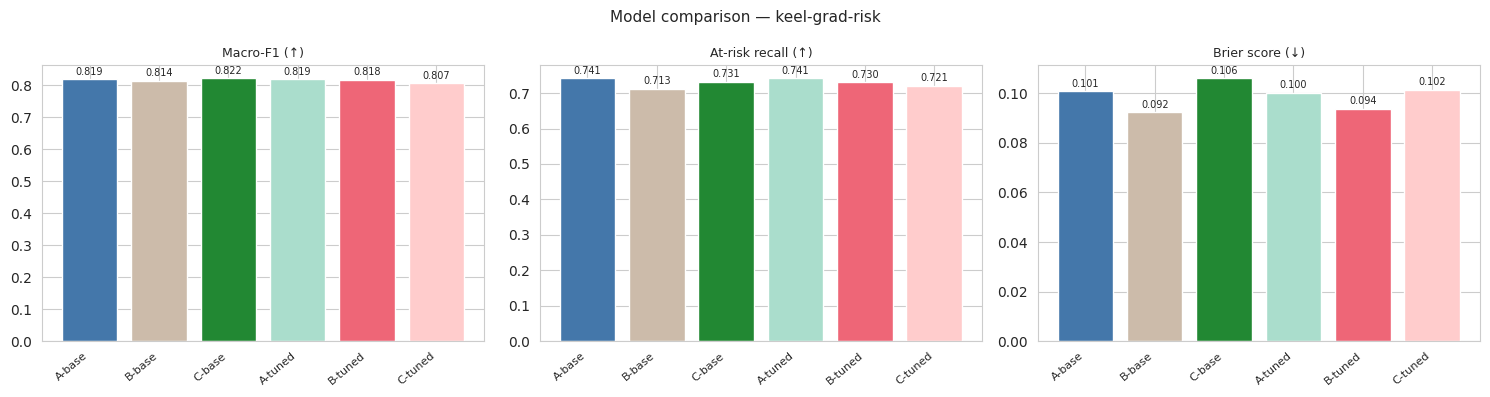

In [11]:
comp_df = pd.DataFrame(metrics_all).T
comp_df = comp_df[["macro_f1", "at_risk_recall", "on_track_recall", "pr_auc", "brier"]]
print("=" * 72)
print("COMPARISON TABLE")
print("=" * 72)
print(comp_df.round(4).to_string())

# ── Grouped bar chart ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
_colors = ["#4477aa", "#ccbbaa", "#228833", "#aaddcc", "#ee6677", "#ffcccc"]
names = list(comp_df.index)

for ax, col, title in zip(
    axes,
    ["macro_f1", "at_risk_recall", "brier"],
    ["Macro-F1 (↑)", "At-risk recall (↑)", "Brier score (↓)"],
):
    vals = comp_df[col].values
    bars = ax.bar(range(len(names)), vals, color=_colors[:len(names)], edgecolor="white")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=40, ha="right", fontsize=8)
    ax.set_title(title, fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Model comparison — keel-grad-risk", fontsize=11)
plt.tight_layout()
plt.savefig(str(ARTIFACTS_DIR / "comparison.png"), dpi=120, bbox_inches="tight")
plt.show()

In [12]:
# Primary: macro_f1; tie-break: at_risk_recall
sorted_runs = comp_df.sort_values(
    ["macro_f1", "at_risk_recall"], ascending=False
)
WINNER_KEY = sorted_runs.index[0]
print(f"Winner: {WINNER_KEY}")
print(comp_df.loc[WINNER_KEY].round(4).to_string())

# Map winner key to the right pipeline
_pipeline_map = {
    "A-base": pipe_lr,        "A-tuned": pipe_lr_tuned,
    "B-base": pipe_rf,        "B-tuned": pipe_rf_tuned,
    "C-base": pipe_hgb,       "C-tuned": pipe_hgb_tuned,
}
winner_pipeline = _pipeline_map[WINNER_KEY]
winner_run_id   = run_ids[WINNER_KEY]
winner_metrics  = metrics_all[WINNER_KEY]

Winner: C-base
macro_f1           0.8215
at_risk_recall     0.7310
on_track_recall    0.9121
pr_auc             0.8337
brier              0.1060


## 7) Safety checks

Two required assertions:
1. `macro_f1 < 0.97` — trivial-guard: data must not be too clean.
2. 100% accuracy on `grad_risk_golden_edge.csv` — obvious cases must always be right.

In [13]:
winner_f1 = winner_metrics["macro_f1"]
assert winner_f1 < 0.97, (
    f"macro_f1={winner_f1:.4f} >= 0.97 trivial guard — data may be too clean."
)
print(f"✓ Trivial guard passed: macro_f1={winner_f1:.4f} < 0.97")

# ── Edge-case gate ─────────────────────────────────────────────────────────
edge_df = pd.read_csv(EDGE_CSV)
X_edge  = edge_df[FEATURE_ORDER].values
y_edge  = edge_df["at_risk"].values
preds_edge = winner_pipeline.predict(X_edge)
edge_acc = (preds_edge == y_edge).mean()

print(f"\nEdge-case accuracy: {edge_acc:.4f}  ({int((preds_edge == y_edge).sum())} / {len(y_edge)})")
assert edge_acc == 1.0, (
    f"Edge-case gate FAILED: accuracy={edge_acc:.4f}. "
    "Examine misclassified rows below."
)
print("✓ Edge-case gate passed: all obvious cases correct")

# Classification report on edge set
print()
print(classification_report(y_edge, preds_edge, target_names=["on-track", "at-risk"], digits=3))

✓ Trivial guard passed: macro_f1=0.8215 < 0.97

Edge-case accuracy: 1.0000  (24 / 24)
✓ Edge-case gate passed: all obvious cases correct

              precision    recall  f1-score   support

    on-track      1.000     1.000     1.000        12
     at-risk      1.000     1.000     1.000        12

    accuracy                          1.000        24
   macro avg      1.000     1.000     1.000        24
weighted avg      1.000     1.000     1.000        24



## 8) Export artifacts

Save to `ARTIFACTS_DIR`:
- `grad_risk.joblib` — the serving model (winner pipeline)
- `grad_risk.onnx` — ONNX export (skipped for HistGB if conversion fails)
- `feature_schema.json` — feature names + order + constants
- `model_card.md` — task, data, results, SHA-256 of served file
- `eval_report.json` — all 6 models + winner metrics

In [14]:
joblib_path = str(ARTIFACTS_DIR / "grad_risk.joblib")
joblib.dump(winner_pipeline, joblib_path)

sha256_joblib = hashlib.sha256(Path(joblib_path).read_bytes()).hexdigest()
print(f"Saved grad_risk.joblib  ({Path(joblib_path).stat().st_size:,} bytes)")
print(f"SHA-256: {sha256_joblib}")

SERVED_FILE = "grad_risk.joblib"
SERVED_SHA256 = sha256_joblib

Saved grad_risk.joblib  (1,091,741 bytes)
SHA-256: e4bef218508c20713654b9eb15a06413c8eb532d9f86440d4236c3535a231f7a


In [15]:
onnx_path = str(ARTIFACTS_DIR / "grad_risk.onnx")
ONNX_OK = False

try:
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    import onnxruntime as ort

    initial_type = [("float_input", FloatTensorType([None, len(FEATURE_ORDER)]))]
    onnx_model = convert_sklearn(winner_pipeline, initial_types=initial_type,
                                  target_opset=17)
    with open(onnx_path, "wb") as f:
        f.write(onnx_model.SerializeToString())

    # Parity check
    sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
    ort_preds = sess.run(["output_label"],
                          {"float_input": X_test[:20].astype(np.float32)})[0]
    sk_preds  = winner_pipeline.predict(X_test[:20])
    match = (ort_preds == sk_preds).mean()
    assert match == 1.0, f"ONNX parity failed: {match:.2%} match"

    sha256_onnx = hashlib.sha256(Path(onnx_path).read_bytes()).hexdigest()
    ONNX_OK = True
    SERVED_FILE   = "grad_risk.onnx"
    SERVED_SHA256 = sha256_onnx
    print(f"✓ ONNX export succeeded  ({Path(onnx_path).stat().st_size:,} bytes)")
    print(f"  SHA-256: {sha256_onnx}")
    print(f"  Parity: {match:.2%} match on 20 test samples")
except Exception as _onnx_err:
    print(f"ONNX conversion skipped: {_onnx_err}")
    print("Serving file: grad_risk.joblib (joblib is the safe path per spec)")

print(f"\nServed file  : {SERVED_FILE}")
print(f"Served SHA256: {SERVED_SHA256}")

✓ ONNX export succeeded  (685,510 bytes)
  SHA-256: fda480982c284cd9928af32af970262459554a71b91175a104925d64cb137687
  Parity: 100.00% match on 20 test samples

Served file  : grad_risk.onnx
Served SHA256: fda480982c284cd9928af32af970262459554a71b91175a104925d64cb137687


In [16]:
# ── feature_schema.json ────────────────────────────────────────────────────
feature_schema = {
    "feature_order": FEATURE_ORDER,
    "n_features": len(FEATURE_ORDER),
    "constants": {
        "EXPECTED_CREDITS_PER_TERM": 15,
        "TREND_WINDOW": 2,
        "HARD_DIFFICULTY_THRESHOLD": 4,
    },
    "target": TARGET,
    "labels": {"0": "on_track", "1": "at_risk"},
}
schema_path = str(ARTIFACTS_DIR / "feature_schema.json")
with open(schema_path, "w") as f:
    json.dump(feature_schema, f, indent=2)
print("feature_schema.json written:")
print(json.dumps(feature_schema, indent=2))

feature_schema.json written:
{
  "feature_order": [
    "cumulative_gpa",
    "gpa_trend",
    "num_failures",
    "num_repeats",
    "progress_rate",
    "pct_complete",
    "planned_credits",
    "planned_workload_index",
    "num_hard_courses"
  ],
  "n_features": 9,
  "constants": {
    "EXPECTED_CREDITS_PER_TERM": 15,
    "TREND_WINDOW": 2,
    "HARD_DIFFICULTY_THRESHOLD": 4
  },
  "target": "at_risk",
  "labels": {
    "0": "on_track",
    "1": "at_risk"
  }
}


In [17]:
# ── eval_report.json ───────────────────────────────────────────────────────
eval_report = {
    "winner": WINNER_KEY,
    "served_file": SERVED_FILE,
    "served_sha256": SERVED_SHA256,
    "winner_metrics": {k: round(v, 4) for k, v in winner_metrics.items()},
    "all_models": {
        k: {m: round(v, 4) for m, v in mv.items()}
        for k, mv in metrics_all.items()
    },
    "edge_case_accuracy": edge_acc,
    "n_train": len(y_train),
    "n_test": len(y_test),
    "at_risk_rate_train": float(y_train.mean().round(4)),
    "at_risk_rate_test": float(y_test.mean().round(4)),
    "seed": SEED,
}
report_path = str(ARTIFACTS_DIR / "eval_report.json")
with open(report_path, "w") as f:
    json.dump(eval_report, f, indent=2)
print(f"eval_report.json written -> {report_path}")
print(json.dumps(eval_report, indent=2))

eval_report.json written -> /content/keel_grad_risk_artifacts/eval_report.json
{
  "winner": "C-base",
  "served_file": "grad_risk.onnx",
  "served_sha256": "fda480982c284cd9928af32af970262459554a71b91175a104925d64cb137687",
  "winner_metrics": {
    "macro_f1": 0.8215,
    "at_risk_recall": 0.731,
    "on_track_recall": 0.9121,
    "pr_auc": 0.8337,
    "brier": 0.106
  },
  "all_models": {
    "A-base": {
      "macro_f1": 0.819,
      "at_risk_recall": 0.7412,
      "on_track_recall": 0.8969,
      "pr_auc": 0.8495,
      "brier": 0.1008
    },
    "B-base": {
      "macro_f1": 0.8144,
      "at_risk_recall": 0.7127,
      "on_track_recall": 0.916,
      "pr_auc": 0.8189,
      "brier": 0.0923
    },
    "C-base": {
      "macro_f1": 0.8215,
      "at_risk_recall": 0.731,
      "on_track_recall": 0.9121,
      "pr_auc": 0.8337,
      "brier": 0.106
    },
    "A-tuned": {
      "macro_f1": 0.819,
      "at_risk_recall": 0.7412,
      "on_track_recall": 0.8969,
      "pr_auc": 0.849,

In [18]:
# ── model_card.md ──────────────────────────────────────────────────────────
model_card_lines = [
    "# Model Card — keel-grad-risk\n",
    "## Task",
    "Binary classification: `at_risk ∈ {0, 1}` given a `(student-state, candidate-plan)` "
    "9-feature vector.",
    "",
    "## Data",
    "**Synthetic.** Generated by `scripts/generate_synthetic_data.py` using a latent-ability",
    "model. Labels are sampled from Bernoulli(sigmoid(risk-logit)) — NOT thresholded.",
    "This model learns the generator's definition of risk, not real-world outcomes.",
    "FERPA prohibits using real student transcripts.",
    f"Train: {len(y_train)} rows  |  Test: {len(y_test)} rows  |  "
    f"At-risk rate: {y_train.mean():.3f} (train) / {y_test.mean():.3f} (test)",
    "",
    "## Three-family comparison",
    "(LR = linear, RF = bagging, HGB = boosting; base + tuned each)",
    "",
    "| Model | macro_f1 | at_risk_recall | on_track_recall | pr_auc | brier |",
    "|---|---|---|---|---|---|",
]
for key, m in metrics_all.items():
    marker = " **← winner**" if key == WINNER_KEY else ""
    model_card_lines.append(
        f"| {key}{marker} | {m['macro_f1']:.4f} | {m['at_risk_recall']:.4f} "
        f"| {m['on_track_recall']:.4f} | {m['pr_auc']:.4f} | {m['brier']:.4f} |"
    )
model_card_lines += [
    "",
    "## Served artifact",
    f"File: `{SERVED_FILE}`",
    f"SHA-256: `{SERVED_SHA256}`",
    "",
    "The model-server refuses to boot if the SHA-256 of the loaded file does not match.",
    "",
    "## Feature order",
    "`" + ", ".join(FEATURE_ORDER) + "`",
    "",
    "## Limitations",
    "- Labels are synthetic — do not present this as predicting real graduation outcomes.",
    "- Minority class (~25%) handled with class weighting, not oversampling.",
    "- No concept drift monitoring; retrain if the student population changes significantly.",
]

card_path = str(ARTIFACTS_DIR / "model_card.md")
with open(card_path, "w") as f:
    f.write("\n".join(model_card_lines))
print(f"model_card.md written -> {card_path}")

model_card.md written -> /content/keel_grad_risk_artifacts/model_card.md


## 9) Register winner → MLflow Model Registry (Production)

In [19]:
# Log artifacts to the winning run, then register
with mlflow.start_run(run_id=winner_run_id):
    mlflow.log_artifact(joblib_path,  "artifacts")
    mlflow.log_artifact(schema_path,  "artifacts")
    mlflow.log_artifact(report_path,  "artifacts")
    mlflow.log_artifact(card_path,    "artifacts")
    mlflow.log_artifact(str(ARTIFACTS_DIR / "eda.png"),        "plots")
    mlflow.log_artifact(str(ARTIFACTS_DIR / "comparison.png"), "plots")
    if ONNX_OK:
        mlflow.log_artifact(onnx_path, "artifacts")
    mlflow.log_param("served_file",   SERVED_FILE)
    mlflow.log_param("served_sha256", SERVED_SHA256)

model_uri = f"runs:/{winner_run_id}/artifacts"
# Register the joblib directly (sklearn-flavour)
with mlflow.start_run(run_id=winner_run_id):
    sig = infer_signature(X_train[:5], winner_pipeline.predict_proba(X_train[:5]))
    mlflow.sklearn.log_model(winner_pipeline, "model", signature=sig)

_reg = mlflow.register_model(f"runs:/{winner_run_id}/model", REGISTRY_NAME)
_client = mlflow.tracking.MlflowClient()
_client.set_registered_model_alias(
    name=REGISTRY_NAME,
    alias="production",
    version=str(_reg.version),
)
print(f"Registered '{REGISTRY_NAME}' v{_reg.version} -> alias 'production'")
print(f"Source run : {winner_run_id}  (Winner: {WINNER_KEY})")

2026/06/12 16:26:34 INFO mlflow.tracking._tracking_service.client: 🏃 View run C-hgb-base at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2/runs/d4c07dcc38074b58888f0b1d8ce728c8.
2026/06/12 16:26:34 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2.
2026/06/12 16:26:45 INFO mlflow.tracking._tracking_service.client: 🏃 View run C-hgb-base at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2/runs/d4c07dcc38074b58888f0b1d8ce728c8.
2026/06/12 16:26:45 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/2.
Successfully registered model 'keel-grad-risk'.
2026/06/12 16:26:46 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: keel-grad-risk, version 1


Registered 'keel-grad-risk' v1 -> alias 'production'
Source run : d4c07dcc38074b58888f0b1d8ce728c8  (Winner: C-base)


Created version '1' of model 'keel-grad-risk'.


## 10) SHA-256 checksums

Copy these into `model_card.md` and verify against the model-server's check.

In [20]:
def _sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()

_artifact_map = {
    "grad_risk.joblib"     : str(ARTIFACTS_DIR / "grad_risk.joblib"),
    "feature_schema.json"  : schema_path,
    "eval_report.json"     : report_path,
}
if ONNX_OK:
    _artifact_map["grad_risk.onnx"] = onnx_path

print("=" * 64)
print("SHA-256 CHECKSUMS")
print("=" * 64)
for name, path in _artifact_map.items():
    p = Path(path)
    if p.exists():
        print(f"  {name:<25} {_sha256(path)}  ({p.stat().st_size:,} bytes)")
    else:
        print(f"  {name:<25} FILE NOT FOUND")
print("=" * 64)

SHA-256 CHECKSUMS
  grad_risk.joblib          e4bef218508c20713654b9eb15a06413c8eb532d9f86440d4236c3535a231f7a  (1,091,741 bytes)
  feature_schema.json       82b81c94b89eec772b9172f0952ad7ccabc7f6a772562855537157a3af60fa8e  (441 bytes)
  eval_report.json          7539d653ba9a4f2dd35774c5816a015da9e1f3e117fece06da886ba9877c73b0  (1,419 bytes)
  grad_risk.onnx            fda480982c284cd9928af32af970262459554a71b91175a104925d64cb137687  (685,510 bytes)


## 11) Export artifacts before the runtime resets

### Option A — Download a zip
```python
from google.colab import files
import zipfile
zip_path = "/content/keel_grad_risk_artifacts.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for f in Path("/content/keel_grad_risk_artifacts").rglob("*"):
        if f.is_file():
            zf.write(f, f.relative_to("/content"))
files.download(zip_path)
```

### What to copy back into the repo
| File | Repo path |
|---|---|
| `grad_risk.joblib` (or `.onnx`) | `ml/grad_risk/artifacts/` |
| `feature_schema.json` | `ml/grad_risk/artifacts/` |
| `model_card.md` | `ml/grad_risk/artifacts/` |
| `eval_report.json` | `ml/grad_risk/artifacts/` |
| `grad_risk_test.csv` | `data/` |

In [22]:
from google.colab import files
import zipfile
zip_path = "/content/keel_grad_risk_artifacts.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for f in Path("/content/keel_grad_risk_artifacts").rglob("*"):
        if f.is_file():
            zf.write(f, f.relative_to("/content"))
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# ── Option B: Backup to Google Drive ───────────────────────────────────────
from google.colab import drive as _gd
import shutil

_gd.mount("/content/drive", force_remount=False)

DRIVE_BACKUP_DIR = Path("/content/drive/MyDrive/keel/grad_risk")
DRIVE_BACKUP_DIR.mkdir(parents=True, exist_ok=True)

_saved = []
for _f in sorted(ARTIFACTS_DIR.rglob("*")):
    if _f.is_file():
        _dest = DRIVE_BACKUP_DIR / _f.relative_to(ARTIFACTS_DIR)
        _dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(_f, _dest)
        _saved.append((_dest.name, _f.stat().st_size))

# Also save the test split
shutil.copy2(str(test_path), str(DRIVE_BACKUP_DIR / "grad_risk_test.csv"))
_saved.append(("grad_risk_test.csv", test_path.stat().st_size))

print(f"✓ {len(_saved)} file(s) backed up to {DRIVE_BACKUP_DIR}")
for _name, _size in _saved:
    print(f"  {_name:<35} {_size:>12,} bytes")

Mounted at /content/drive
✓ 8 file(s) backed up to /content/drive/MyDrive/keel/grad_risk
  comparison.png                            54,203 bytes
  eda.png                                  165,129 bytes
  eval_report.json                           1,419 bytes
  feature_schema.json                          441 bytes
  grad_risk.joblib                       1,091,741 bytes
  grad_risk.onnx                           685,510 bytes
  model_card.md                              1,706 bytes
  grad_risk_test.csv                        72,251 bytes
